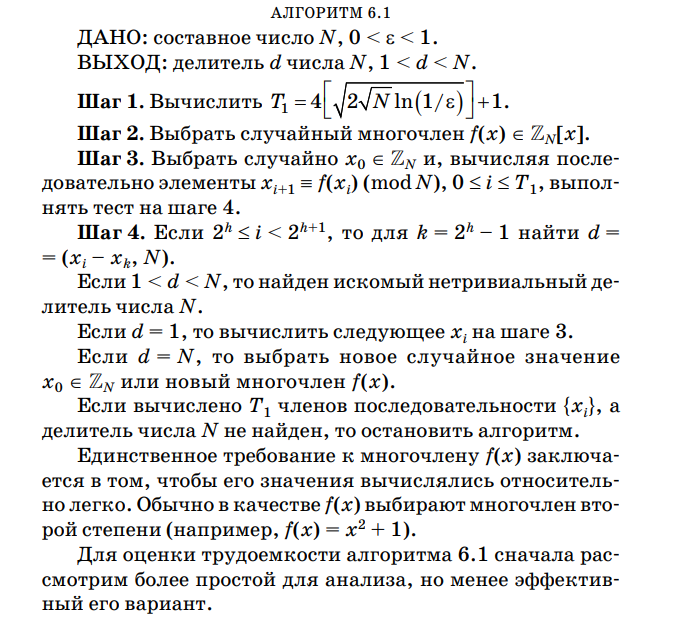

In [14]:
from math import floor, sqrt, log
import random


def gcd_by_euclid(a, b):
    while a != 0:
        b, a = a, b % a

    return abs(b)

def find_factor_by_pollard(N, eps = 0.01, x0_seed = 108):
    T1 = 4 * floor((sqrt(2 * sqrt(N) * log(1 / eps)))) + 1
    polynomial = lambda x: x * x + 1

    random.seed(x0_seed)

    epoch_h = 0

    # x = random.randint(0, N - 1)
    x = 2
    x_k = x
    print(f"Info: Random x0 = {x}")
    for i in range(1, T1 + 1):
        x = polynomial(x) % N
        d = gcd_by_euclid((x - x_k), N)

        if 1 < d < N:
            print(f"Success: d-factor {d} found")
            return d

        elif d == N:
            print("Fail: Choose new x0 or polynomial")
            return None

        # Set new epoch_h for powers of 2.  k = 2^h – 1
        if i == (2 ** (epoch_h + 1)) - 1:
            x_k = x
            epoch_h += 1

    return d

find_factor_by_pollard(1022)

Info: Random x0 = 2
Success: d-factor 7 found


7